In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
lr = xr.open_dataset('latent_representations_zmean.nc')

In [3]:
lr

<xarray.Dataset> Size: 528kB
Dimensions:     (time: 6000, latent_dim: 20)
Coordinates:
  * time        (time) int64 48kB 0 1 2 3 4 5 ... 5994 5995 5996 5997 5998 5999
  * latent_dim  (latent_dim) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
Data variables:
    z_mean      (time, latent_dim) float32 480kB ...
Attributes:
    model:        beta-VAE
    random_seed:  1
    description:  Latent-Space Representations (0.0005) from encoder (z_mean ...

In [4]:
# check relation to enso phase
oni_e3sm = xr.open_dataset('oni_e3sm_0402.nc')

In [5]:
latent_representations = lr['z_mean']

In [6]:
latent_representations

<xarray.DataArray 'z_mean' (time: 6000, latent_dim: 20)> Size: 480kB
[120000 values with dtype=float32]
Coordinates:
  * time        (time) int64 48kB 0 1 2 3 4 5 ... 5994 5995 5996 5997 5998 5999
  * latent_dim  (latent_dim) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19

In [7]:
# create enso labels object
enso_labels = oni_e3sm['enso_phase'].values

In [8]:
# Make a DataFrame combining both
ds_latent = pd.DataFrame(latent_representations)
ds_latent['ENSO Phase'] = enso_labels

# Now you can filter by phase
el_nino_events = ds_latent[ds_latent['ENSO Phase'] == 'El Niño']
la_nina_events = ds_latent[ds_latent['ENSO Phase'] == 'La Niña']
neutral_events = ds_latent[ds_latent['ENSO Phase'] == 'Neutral']

In [9]:
ds_latent

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,ENSO Phase
0,-0.122581,0.256039,0.631254,0.406308,0.622883,0.740388,-0.386918,-2.058429,0.771955,0.694181,...,-0.685798,-0.241057,-0.137020,-0.970146,-0.291788,1.104128,0.094088,-1.557253,0.287553,Neutral
1,-0.801713,-0.397866,0.173398,0.685808,0.228763,1.371736,-0.871896,-1.614241,0.453720,-0.166341,...,0.215707,0.032036,0.879869,-0.562252,-0.103897,1.017803,-1.829165,-1.253711,0.527645,Neutral
2,-0.748004,0.280142,0.698139,0.043764,0.666167,0.688260,-0.489472,-2.039294,0.928185,-0.003459,...,0.265669,0.338606,0.501580,-0.679423,0.433861,0.422344,-0.338093,-1.310434,-0.049082,Neutral
3,-1.378326,-0.207716,-0.526224,-0.113530,0.325223,0.110344,-0.354136,-0.332296,0.888672,0.282100,...,0.733365,0.616834,-0.155955,-1.328576,-0.922442,0.095596,-1.975232,-1.416741,-0.198346,Neutral
4,-0.864734,-0.124905,-0.428202,-0.868222,1.473393,-0.281681,0.012625,-0.534546,0.798099,-0.531760,...,0.185609,0.654036,0.522314,-0.395266,-0.341092,-0.055027,-1.671070,-0.477284,-0.301728,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,-0.960880,-1.423229,0.151629,0.082804,1.409209,1.247145,-0.965718,-1.461018,-0.888685,-1.074345,...,-1.117328,-1.169270,-1.208558,0.479936,-0.874124,0.937901,0.745540,0.655118,1.254958,Neutral
5996,-1.564938,-1.531151,0.272695,0.212821,1.693215,1.397351,-0.940511,-0.853563,-1.158123,-0.660902,...,-1.300831,-0.054585,-0.489494,0.093885,-0.631271,0.929869,1.298133,1.429621,0.806340,Neutral
5997,-2.067489,-1.404757,-0.451653,0.580562,0.983965,1.068231,-0.923114,-1.078918,-0.806894,-0.915854,...,-1.456651,0.015418,-0.509616,-0.264286,-0.494185,0.636357,0.864929,1.074722,0.670839,La Niña
5998,-1.990197,-0.931821,0.233562,0.641836,0.854064,0.899676,-0.982391,-1.460220,-1.056757,-0.645816,...,-1.362263,-0.166420,-0.708356,-0.530025,-0.697482,0.961948,1.004048,0.483722,1.256745,La Niña


In [10]:
# same distribution using (mu) as (z)
print(el_nino_events.shape,
      la_nina_events.shape,
      neutral_events.shape
     )

(831, 21) (819, 21) (4350, 21)


In [11]:
# combine into single dataframe
# remove neutral events
ds_combine = pd.concat([el_nino_events,
                        la_nina_events],
                       ignore_index=True
                      )

In [12]:
ds_combine

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,ENSO Phase
0,0.942212,0.154506,-0.311750,-0.516630,0.246214,-0.448879,-0.056114,0.507019,1.071894,-0.776587,...,1.350158,-0.195860,0.345387,-0.100537,-0.168453,-0.192120,-1.152681,-0.427940,-0.979755,El Niño
1,1.160895,-0.292795,-0.623796,-0.995607,0.785800,-1.224236,-0.371687,0.513703,-0.365212,0.712642,...,1.140465,0.158653,0.352911,-0.049518,-0.729586,-0.363468,-0.563538,-0.601178,-0.299793,El Niño
2,1.311602,-0.615024,-0.344124,0.211342,0.637386,-1.097940,0.617916,-0.575376,-0.430715,-0.478929,...,1.056027,0.095125,0.058333,0.080615,-0.070592,-0.976233,0.007353,-0.086219,-0.400626,El Niño
3,1.925563,-0.485059,-0.573044,0.131983,0.446961,-1.292148,-0.656153,-1.074370,-0.899083,0.944047,...,0.131837,-0.099289,0.066734,0.693172,0.053425,-0.548699,0.873404,-0.796920,0.386043,El Niño
4,0.953095,-0.447448,-0.865616,1.191645,0.443549,-0.888606,-0.687031,-1.533696,-0.494178,0.079077,...,-0.203938,-1.072664,0.283681,1.298513,-0.322469,-0.504593,0.601237,-0.159028,0.183582,El Niño
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1645,-0.850857,0.391130,0.299424,-0.117364,-0.614910,-0.770499,-0.897120,-1.839542,0.641418,-0.901930,...,-0.323363,0.552679,-0.250745,-0.266811,-0.768125,1.062781,-0.368215,-0.823944,0.599013,La Niña
1646,-0.116629,1.011491,0.739942,-0.171769,0.739782,-0.667875,-0.513381,-1.336629,0.318530,-1.152956,...,-0.414174,0.220026,0.334704,0.158434,-0.545835,1.188517,0.223750,-1.060388,0.344432,La Niña
1647,-0.313634,-0.526223,-0.015468,0.710803,-0.254718,-0.063930,-0.386999,-0.701743,1.061467,-1.353783,...,-0.752759,-0.536194,0.764084,-1.040081,-0.222187,1.517120,-0.972243,-0.688994,0.168900,La Niña
1648,-2.067489,-1.404757,-0.451653,0.580562,0.983965,1.068231,-0.923114,-1.078918,-0.806894,-0.915854,...,-1.456651,0.015418,-0.509616,-0.264286,-0.494185,0.636357,0.864929,1.074722,0.670839,La Niña


In [13]:
# melt into long format for seaborn
ds_melt = ds_combine.melt(id_vars='ENSO Phase',
                          var_name='Latent Dimension Index', 
                          value_name='Value'
                         )

In [14]:
ds_melt

,ENSO Phase,Latent Dimension Index,Value
0,El Niño,0,0.942212
1,El Niño,0,1.160895
2,El Niño,0,1.311602
3,El Niño,0,1.925563
4,El Niño,0,0.953095
...,...,...,...
32995,La Niña,19,0.599013
32996,La Niña,19,0.344432
32997,La Niña,19,0.168900
32998,La Niña,19,0.670839


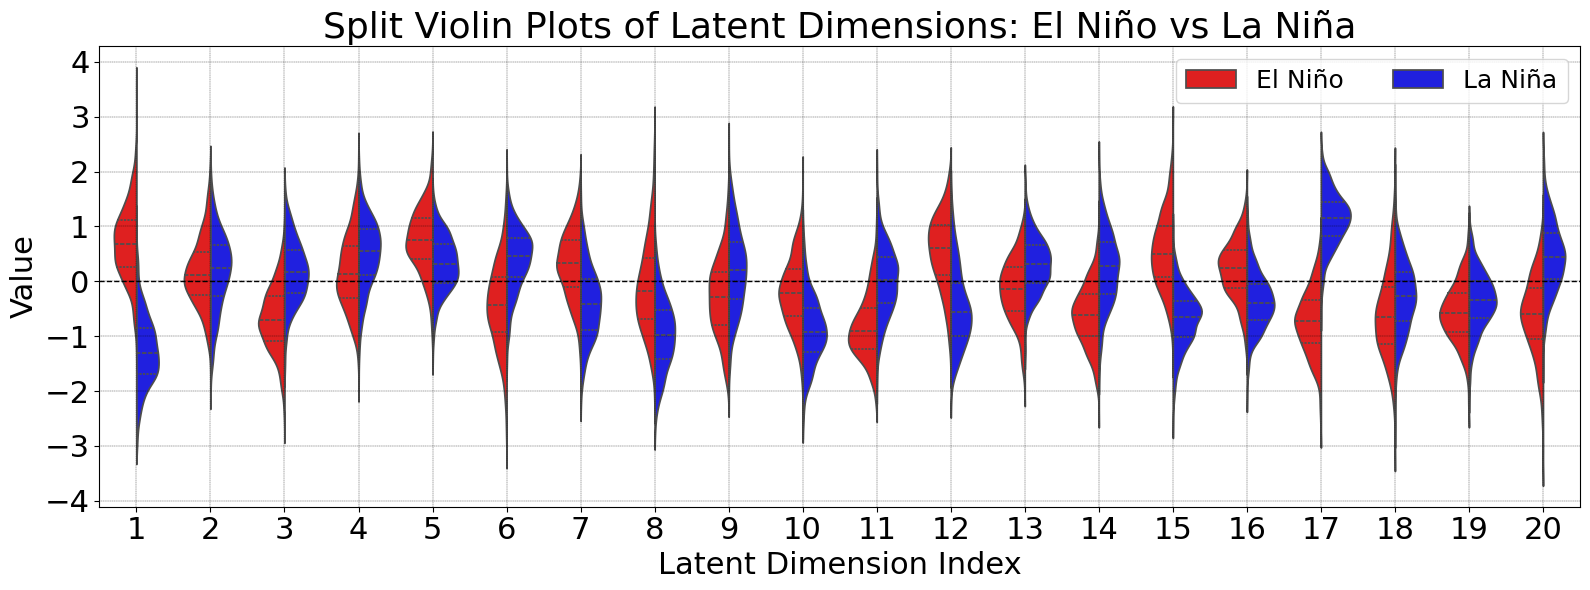

In [15]:
# Plot split violin
plt.figure(figsize=(16, 6))
sns.violinplot(
    data=ds_melt,
    x='Latent Dimension Index',
    y='Value',
    hue='ENSO Phase',
    split=True,
    palette={'El Niño': 'red', 'La Niña': 'blue'},
    inner='quartile'
)
plt.legend(fontsize=18, ncol=2)
plt.xticks(ticks=range(20), labels=range(1, 21), rotation=0, fontsize=22)
plt.yticks(rotation=0, fontsize=22)
plt.xlabel('Latent Dimension Index', fontsize=22)
plt.ylabel('Value', fontsize=22)
plt.axhline(y=0, color='black', linestyle='--', lw=1)
plt.title('Split Violin Plots of Latent Dimensions: El Niño vs La Niña', fontsize=26)
plt.grid(True, linestyle='--', color='k', lw=0.25)
plt.tight_layout()
#plt.savefig('violinplots_mu_0306.pdf', bbox_inches='tight')
plt.show()